# Exercício 4 - AutoEncoders e Representation Learning com Fashion-MNIST dataset

## Contexto do Problema

Vamos implementar dois modelos: um Autoencoder Convolucional e um Denoising Autoencoder (DAE) usando o dataset Fashion-MNIST.

A ideia é entender como redes neurais conseguem aprender representações comprimidas dos dados (o chamado latent space) e depois usar essas representações para reconstruir a imagem original.

Além disso, vamos testar um cenário mais difícil: reconstruir imagens mesmo quando elas estão com ruído. Isso ajuda a entender como redes podem aprender representações mais robustas dos dados visuais.

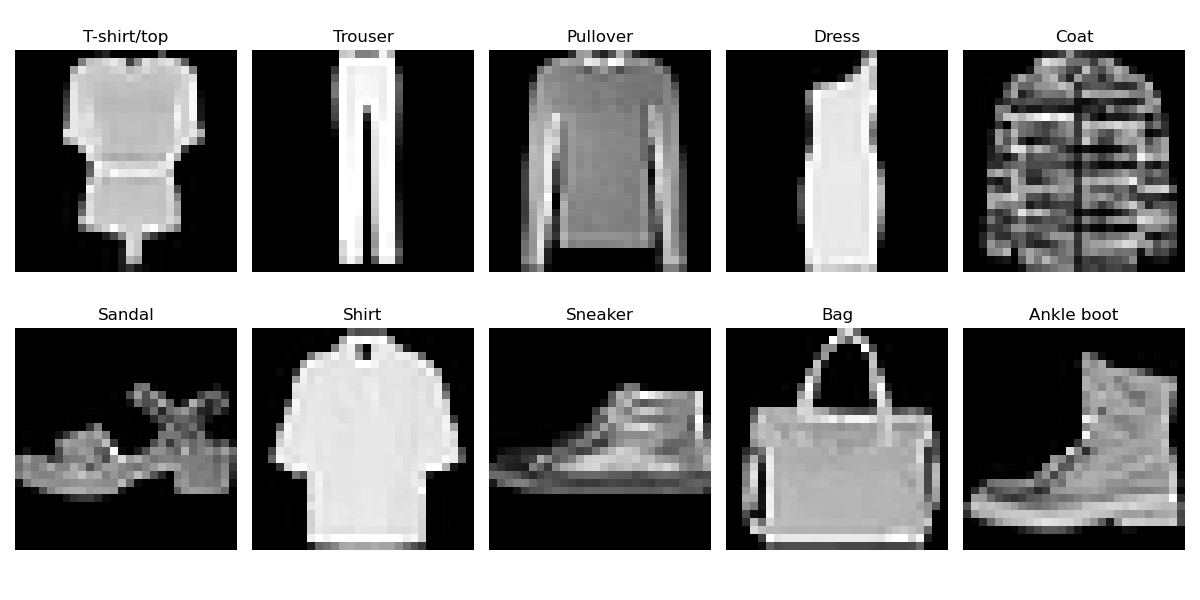

Um Autoencoder é uma rede neural não supervisionada treinada para reproduzir a própria entrada na saída.

Composto por duas partes:

 Encoder: transforma a entrada em uma representação comprimida

* ℎ = 𝑓(𝑥)


Decoder: reconstrói a entrada a partir dessa representação

* 𝑟 = 𝑔(ℎ)

A camada intermediária
ℎ
h é chamada de código latente (latent space). Ela funciona como uma representação compacta da informação original.

Quando obrigamos essa representação a ter menos dimensões que a entrada, o modelo precisa aprender quais características realmente importam nos dados, descartando redundâncias.

Esse processo faz com que o autoencoder capture estruturas relevantes do dataset, algo amplamente discutido na literatura de deep learning

(Goodfellow, Bengio & Courville, 2016).

## Loading do Dataset e Import de bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

SEED = 3
torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Usando: cuda


In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Treino samples: {len(train_dataset)}")
print(f"Teste samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]

Treino samples: 60000
Teste samples: 10000


## Visualização dos dados

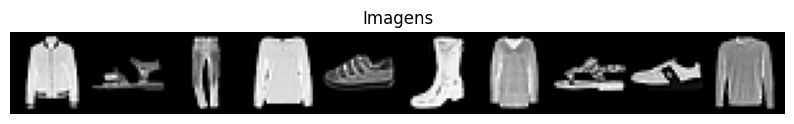

In [4]:
def imshow(img, title="Imagens"):
    npimg = img.numpy()
    plt.figure(figsize=(10, 2))
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:10], nrow=10))

## Arquitetura do Autoencoder

Utilizamos Autoencoder Convolucional, que é mais adequado para imagens do que camadas densas.

Camadas convolucionais conseguem explorar padrões espaciais locais, como bordas, texturas e formas.

A arquitetura é dividida em duas partes.

Encoder

O encoder reduz gradualmente a dimensão espacial da imagem:

* Utilizamos camadas Conv2d

* Stride igual a 2 para reduzir a resolução

* A imagem 28 × 28 é comprimida até 7 × 7

* Ao mesmo tempo, aumentamos o número de canais (features) até 32

Isso cria uma representação compacta da imagem no espaço latente.

Decoder

O decoder faz o processo inverso:

* Utiliza ConvTranspose2d

* Reconstrói gradualmente a resolução da imagem

* Faz o upsampling de 7 × 7 de volta para 28 × 28

* Na última camada usamos ativação Sigmoid, garantindo que os pixels reconstruídos fiquem no intervalo [0, 1], compatível com a normalização do dataset.

In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # Encoder: [Batch, 1, 28, 28] -> [Batch, 32, 7, 7]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> [16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> [32, 7, 7]
            nn.ReLU()
        )

        # Decoder: [Batch, 32, 7, 7] -> [Batch, 1, 28, 28]
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> [16, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> [1, 28, 28]
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

model = ConvAutoencoder().to(device)
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


## Treinamento Modular

Para organizar melhor o experimento, implementamos uma função de treinamento reutilizável.

Esse erro mede a diferença média entre cada pixel da imagem original 𝑥
x e da imagem reconstruída
𝑥^.

O MSE é uma escolha comum para autoencoders porque:

* Penaliza diferenças pixel a pixel

* Funciona bem para reconstrução de imagem

* É estável durante o treinamento

In [6]:
def train_model(model, train_loader, epochs, noise_factor=0.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for data in train_loader:
            imgs, _ = data
            imgs = imgs.to(device)

            if noise_factor > 0.0:
                noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
                noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)
                inputs = noisy_imgs
            else:
                inputs = imgs

            outputs = model(inputs)

            loss = criterion(outputs, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Época [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

    return loss_history

## Treinando o Autoencoder

In [7]:
EPOCHS = 10
print("Treinando Autoencoder...")
standard_loss_history = train_model(model, train_loader, epochs=EPOCHS, noise_factor=0.0)

Treinando Autoencoder...
Época [1/10], Loss: 0.0265
Época [2/10], Loss: 0.0038
Época [3/10], Loss: 0.0025
Época [4/10], Loss: 0.0018
Época [5/10], Loss: 0.0015
Época [6/10], Loss: 0.0012
Época [7/10], Loss: 0.0011
Época [8/10], Loss: 0.0010
Época [9/10], Loss: 0.0009
Época [10/10], Loss: 0.0008


## Reconstruindo Resultados e Curva de Loss

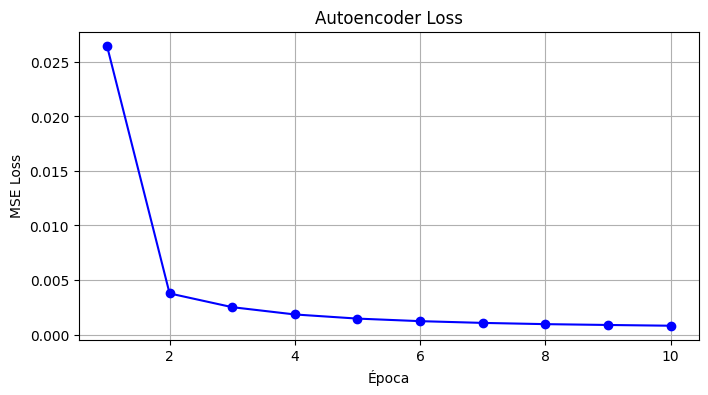

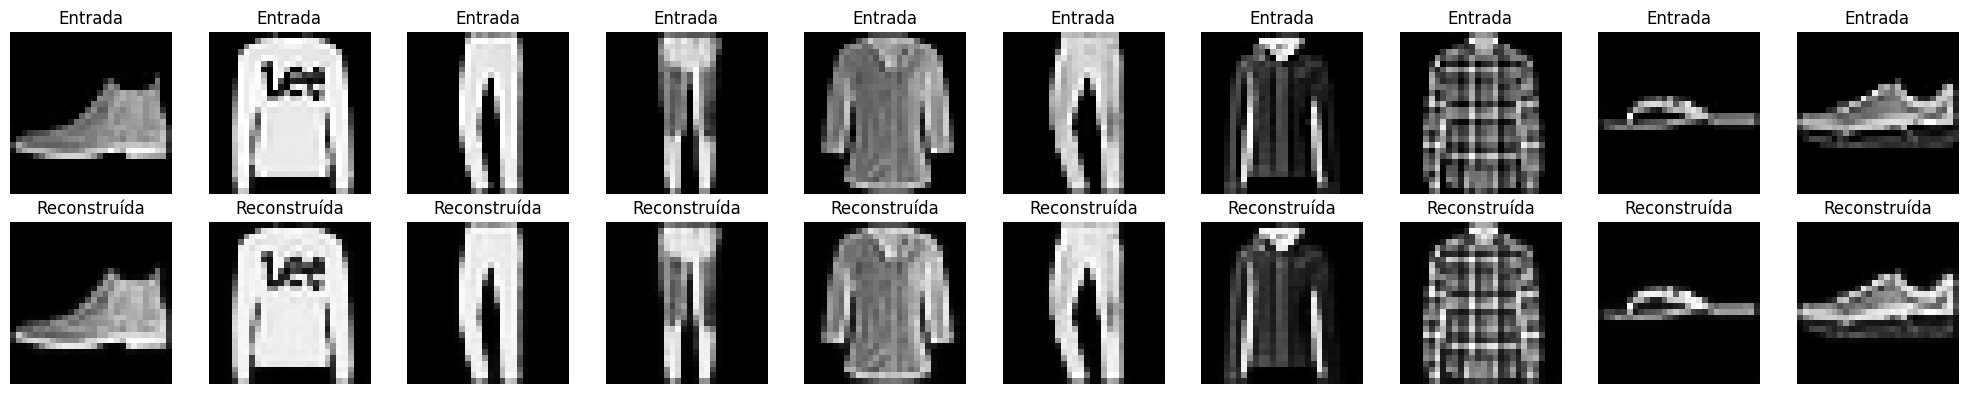

In [8]:
def plot_loss(loss_history, title="Curva de Loss Treinamento"):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='b')
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.show()

def plot_reconstructions(model, test_loader, n=10, noise_factor=0.0):
    model.eval()
    dataiter = iter(test_loader)
    clean_imgs, _ = next(dataiter)

    if noise_factor > 0.0:
        inputs = clean_imgs + noise_factor * torch.randn_like(clean_imgs)
        inputs = torch.clamp(inputs, 0., 1.)
    else:
        inputs = clean_imgs

    inputs = inputs.to(device)

    with torch.no_grad():
        reconstructed = model(inputs)

    inputs = inputs.cpu()
    reconstructed = reconstructed.cpu()
    clean_imgs = clean_imgs.cpu()

    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(2 if noise_factor == 0.0 else 3, n, i + 1)
        plt.imshow(inputs[i].squeeze(), cmap='gray')
        ax.set_title("Entrada" if noise_factor == 0.0 else "Input Ruído")
        ax.axis('off')

        ax = plt.subplot(2 if noise_factor == 0.0 else 3, n, i + 1 + n)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        ax.set_title("Reconstruída")
        ax.axis('off')

        if noise_factor > 0.0:
            ax = plt.subplot(3, n, i + 1 + 2*n)
            plt.imshow(clean_imgs[i].squeeze(), cmap='gray')
            ax.set_title("Original")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_loss(standard_loss_history, title="Autoencoder Loss")
plot_reconstructions(model, test_loader, n=10, noise_factor=0.0)

## Estratégia de Denoising do Autoencoder

Um Denoising Autoencoder (DAE) é treinado para reconstruir uma imagem limpa a partir de uma versão corrompida por ruído.

 Em vez de aprender apenas a copiar a entrada, o modelo precisa remover o ruído e recuperar a estrutura original da imagem. Para conseguir fazer isso, ele acaba aprendendo padrões mais profundos dos dados, como formas, bordas e texturas.

Esse tipo de treinamento força a rede a aprender algo próximo da estrutura real da distribuição dos dados, em vez de apenas memorizar exemplos específicos

(Vincent et al., 2008).


Neste experimento utilizamos ruído Gaussiano, que é adicionado dinamicamente durante o treinamento.

Treinando Denoising Autoencoder...
Época [1/10], Loss: 0.0377
Época [2/10], Loss: 0.0127
Época [3/10], Loss: 0.0118
Época [4/10], Loss: 0.0114
Época [5/10], Loss: 0.0111
Época [6/10], Loss: 0.0109
Época [7/10], Loss: 0.0107
Época [8/10], Loss: 0.0106
Época [9/10], Loss: 0.0105
Época [10/10], Loss: 0.0104


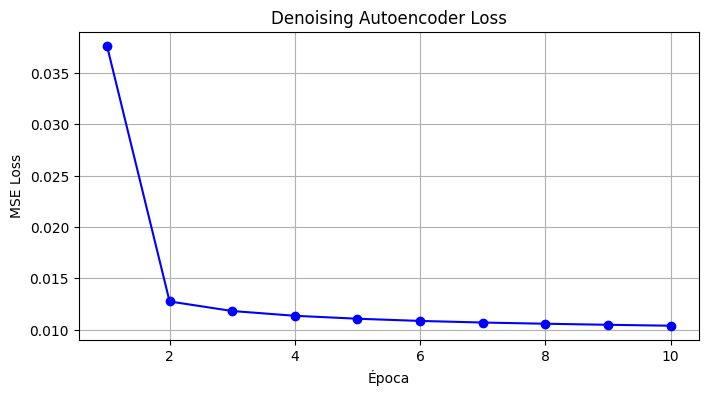

In [9]:
dae_model = ConvAutoencoder().to(device)

NOISE_FACTOR = 0.3

print("Treinando Denoising Autoencoder...")
dae_loss_history = train_model(dae_model, train_loader, epochs=EPOCHS, noise_factor=NOISE_FACTOR)

plot_loss(dae_loss_history, title="Denoising Autoencoder Loss")

## Comparação das Reconstruções e Análise Qualitativa

Resultados do Denoising Autoencoder:


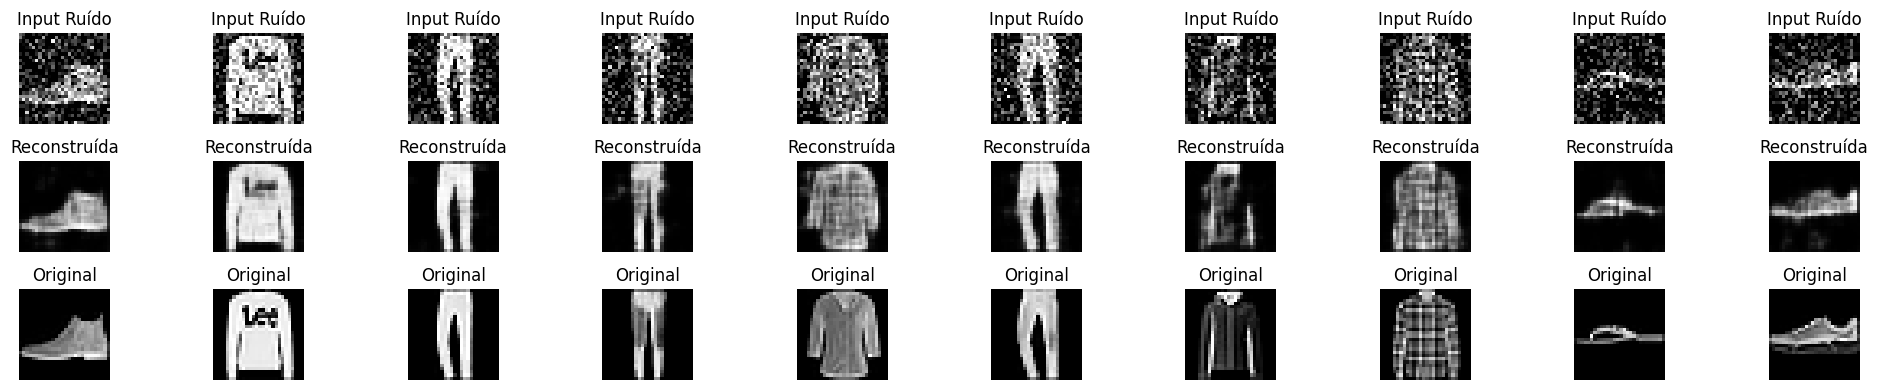

In [10]:
print("Resultados do Denoising Autoencoder:")
plot_reconstructions(dae_model, test_loader, n=10, noise_factor=NOISE_FACTOR)